In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
clean_df = pd.read_csv('clean_mobile_game_dataset.csv')

# Initialize data types

In [4]:
clean_df['LastPurchaseDate'] = pd.to_datetime(clean_df['LastPurchaseDate'], format = '%Y-%m-%d') 
clean_df['Age'] = clean_df['Age'].astype('Int64')
clean_df['FirstPurchaseDaysAfterInstall'] = clean_df['FirstPurchaseDaysAfterInstall'].astype('Int64')
clean_df['GameGenre'] = clean_df['GameGenre'].astype('category')

# Comparing Players by Country and Device

In [109]:
clean_df.groupby(['Country', 'Device'])[['AverageSessionLength', 'Age']]\
                .mean().round().sort_values(by = 'Country', ascending = False).reset_index()

,Country,Device,AverageSessionLength,Age
0,USA,iOS,19.0,33.0
1,USA,Android,19.0,34.0
2,UK,iOS,21.0,35.0
3,UK,Android,20.0,34.0
4,Turkey,iOS,20.0,31.0
5,Turkey,Android,21.0,31.0
6,Switzerland,iOS,23.0,32.0
7,Switzerland,Android,21.0,31.0
8,Sweden,iOS,22.0,34.0
9,Sweden,Android,19.0,35.0


# No meaningful differences were observed between Android and iOS users across countries in terms of average player age or average session length. The results suggest a consistent distribution of these variables across both device types.

# Counting Players Age

In [128]:
age_counts = clean_df['Age'].value_counts().sort_index().reset_index()

age_counts

,Age,count
0,13,63
1,14,73
2,15,55
3,16,68
4,17,72
5,18,69
6,19,70
7,20,66
8,21,84
9,22,70


# Players Exact Age Bar Chart 

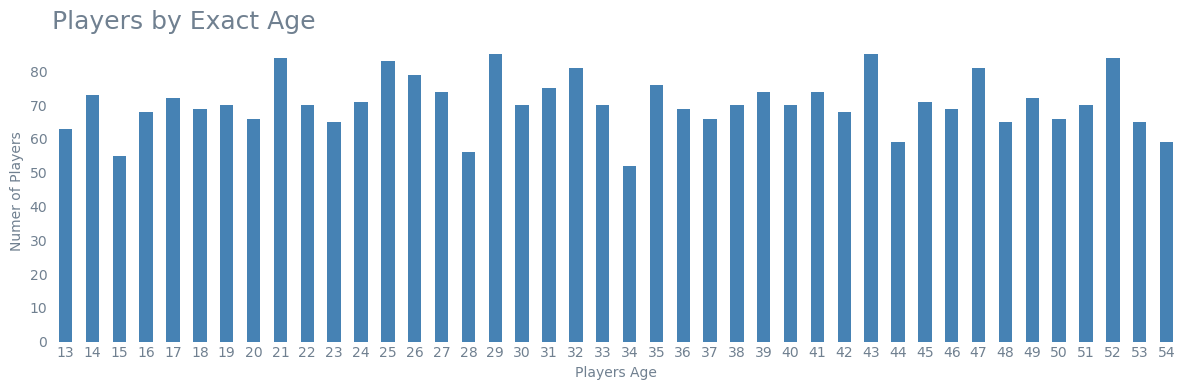

In [250]:
ax = age_counts.plot(kind='bar', x='Age', y='count', figsize = (12,4), color = 'steelblue')

plt.title('Players by Exact Age',
         fontsize = 18, pad = 8, loc='left', color = 'slategray')

plt.xlabel('Players Age', color='slategray')
plt.ylabel('Numer of Players', color='slategray')

plt.xticks(rotation = 0)

ax.tick_params(
    axis = 'x',
    colors = 'slategray',
    length = 0)

ax.tick_params(
    axis = 'y',
    colors = 'slategray',
    length = 0)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

plt.legend().remove()

plt.tight_layout()

plt.show()

# Player age appears to be well distributed across the dataset, with no significant concentration around a specific age. This suggests that the player base is relatively balanced and that the analyses performed later are not strongly influenced by a single age group.

# Session Count Histogram 

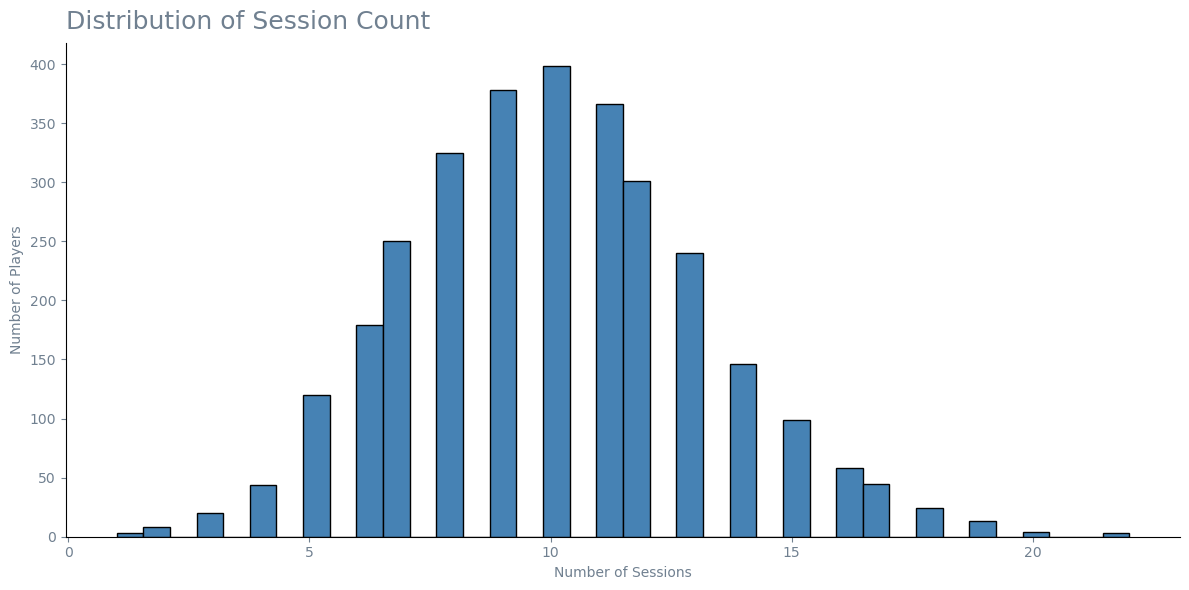

In [244]:
fig, ax = plt.subplots(figsize=(12,6))

ax.hist(
    clean_df['SessionCount'],
    bins='auto',
    color='steelblue',
    edgecolor='black',
    linewidth=1.0
)

ax.set_title(
    'Distribution of Session Count',
    fontsize=18,
    color='slategray',
    loc='left',
    pad=10
)

ax.set_xlabel('Number of Sessions', color='slategray')
ax.set_ylabel('Number of Players', color='slategray')

ax.tick_params(colors='slategray')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# The Session Count distribution is concentrated between approximately 5 and 15 sessions, with the highest frequency around 10 sessions. Very few players exhibit extremely low or exceptionally high session counts, suggesting that overall player activity is relatively consistent across the dataset.

# Total Revenue 

In [13]:
clean_df['InAppPurchaseAmount'].sum().round(2)

296259.31

# Device Distribution

In [15]:
clean_df['Device'].value_counts()

Device
Android    1738
iOS        1226
Name: count, dtype: int64

# Average In App Purchase Amount by Device  

In [297]:
clean_df.groupby('Device',)['InAppPurchaseAmount'].mean().round(2).sort_values(ascending = False).reset_index()

,Device,InAppPurchaseAmount
0,iOS,111.05
1,Android,94.67


# Sum Of Total In App Purchase Amount by Device

In [19]:
clean_df.groupby('Device',)['InAppPurchaseAmount'].sum().round(2).sort_values(ascending = False).reset_index()

,Device,InAppPurchaseAmount
0,Android,157721.61
1,iOS,129487.62


# To compare average in-app purchase amounts between Android and iOS users, the grouped results were reshaped using `unstack()`, creating a separate column for each device.

In [21]:
average_revenue_by_country = clean_df.groupby(['Country', 'Device'])['InAppPurchaseAmount'].mean().round(2).unstack()
average_revenue_by_country

Device,Android,iOS
Country,,
Afghanistan,211.30,255.23
Australia,34.63,50.36
Bangladesh,99.86,261.94
Brazil,73.90,31.28
Canada,146.87,157.57
China,90.77,34.70
Denmark,169.75,108.90
Egypt,71.86,67.41
France,26.21,40.92


# Calculating Revenue Difference Between Devices

In [23]:
average_revenue_by_country['RevenueDifference'] = (
    average_revenue_by_country['Android']
    - average_revenue_by_country['iOS']
    ).round(2)

In [24]:
average_revenue_by_country

Device,Android,iOS,RevenueDifference
Country,,,
Afghanistan,211.30,255.23,-43.93
Australia,34.63,50.36,-15.73
Bangladesh,99.86,261.94,-162.08
Brazil,73.90,31.28,42.62
Canada,146.87,157.57,-10.70
China,90.77,34.70,56.07
Denmark,169.75,108.90,60.85
Egypt,71.86,67.41,4.45
France,26.21,40.92,-14.71


# NumPy's `np.where()` function was used to perform a conditional comparison between Android and iOS average revenue.

# A new column (`Winner_Device`) was created to identify which platform generates higher average in-app purchase revenue for each country.

In [27]:
average_revenue_by_country['Winner_Device'] = np.where(
    average_revenue_by_country['Android'] > average_revenue_by_country['iOS'],
    'Android',
    'iOS'
)

In [28]:
average_revenue_by_country

Device,Android,iOS,RevenueDifference,Winner_Device
Country,,,,
Afghanistan,211.30,255.23,-43.93,iOS
Australia,34.63,50.36,-15.73,iOS
Bangladesh,99.86,261.94,-162.08,iOS
Brazil,73.90,31.28,42.62,Android
Canada,146.87,157.57,-10.70,iOS
China,90.77,34.70,56.07,Android
Denmark,169.75,108.90,60.85,Android
Egypt,71.86,67.41,4.45,Android
France,26.21,40.92,-14.71,iOS


# Although Android accounts for the largest share of players, iOS users tend to generate higher average in-app purchase revenue across many countries. Nevertheless, the winning platform varies by market, highlighting that device monetization is not consistent worldwide.

In [307]:
top_10_genre_by_purchase_amount = clean_df.groupby('GameGenre', observed=True)[['SessionCount','InAppPurchaseAmount','AverageSessionLength']]\
                                .mean().round().sort_values(by ='InAppPurchaseAmount', ascending=False).reset_index()
top_10_genre_by_purchase_amount

,GameGenre,SessionCount,InAppPurchaseAmount,AverageSessionLength
0,Racing,10.0,160.0,20.0
1,Battle Royale,10.0,157.0,21.0
2,Strategy,10.0,143.0,19.0
3,Fighting,10.0,141.0,20.0
4,MOBA,10.0,140.0,21.0
5,MMORPG,10.0,98.0,20.0
6,Adventure,10.0,97.0,21.0
7,Role Playing,10.0,93.0,20.0
8,Simulation,10.0,85.0,20.0
9,Card,10.0,84.0,21.0


# While Session Count and Average Session Length are remarkably consistent across game genres, Average In-App Purchase Amount differs considerably. This suggests that similar levels of player activity do not necessarily translate into similar monetization outcomes. Further investigation would be required to identify the factors driving these revenue differences across genres.

# Payment Method Distribution 

In [31]:
clean_df['PaymentMethod'].value_counts().reset_index()

,PaymentMethod,count
0,Debit Card,433
1,Google Pay,431
2,Gift Card,422
3,Carrier Billing,417
4,Credit Card,410
5,Paypal,401
6,Apple Pay,374


# Players Engagement Segmentation

### Spending Segments Range

In [239]:
spending_range = clean_df.groupby('SpendingSegment', observed=True)['InAppPurchaseAmount'].agg(['min','max']).reset_index()
spending_range

,SpendingSegment,min,max
0,Dolphin,20.53,497.91
1,Minnow,0.00,20.00
2,Whale,608.21,4964.45


### Players were classified into three spending segments based on their total in-app purchase amount. The ranges show a clear distinction between low spenders (Minnows), medium spenders (Dolphins), and high-value players (Whales), providing a structured framework for comparing player behavior across monetization segments.

In [34]:
spending_summary = (clean_df
                    .groupby('SpendingSegment')['InAppPurchaseAmount']
                    .agg(
                        TotalPurchase='sum',
                        Players='count')
                        .round(2)
                        .reset_index()
                        .sort_values(by = 'TotalPurchase', ascending=False))

In [35]:
spending_summary['AveragePurchasePerPlayer'] = (spending_summary['TotalPurchase'] / spending_summary['Players']).round(2) 
spending_summary

,SpendingSegment,TotalPurchase,Players,AveragePurchasePerPlayer
2,Whale,175583.14,63,2787.03
0,Dolphin,96288.80,392,245.63
1,Minnow,24387.37,2433,10.02


In [37]:
clean_df.groupby('SpendingSegment')[['InAppPurchaseAmount', 'SessionCount', 'AverageSessionLength', 'Age']]\
                     .mean().round(0).reset_index().sort_values(by = 'InAppPurchaseAmount', ascending=False)

,SpendingSegment,InAppPurchaseAmount,SessionCount,AverageSessionLength,Age
2,Whale,2787.0,11.0,18.0,35.0
0,Dolphin,246.0,10.0,20.0,33.0
1,Minnow,10.0,10.0,20.0,34.0


In [38]:
(pd.crosstab(clean_df['SpendingSegment'], clean_df['Device']
                       , normalize='index') * 100 ).round(2)

Device,Android,iOS
SpendingSegment,,
Dolphin,57.67,42.33
Minnow,58.81,41.19
Whale,57.81,42.19


In [39]:
(pd.crosstab(clean_df['SpendingSegment'], clean_df['GameGenre']
                           , normalize='index') * 100).round(2)


GameGenre,Action RPG,Adventure,Battle Royale,Card,Casual,Fighting,MMORPG,MOBA,Puzzle,Racing,Role Playing,Sandbox,Simulation,Sports,Strategy
SpendingSegment,,,,,,,,,,,,,,,
Dolphin,5.96,9.68,6.20,4.96,5.96,8.19,7.20,5.71,5.21,7.44,5.96,7.20,7.44,7.20,5.71
Minnow,6.54,5.21,6.30,7.18,7.18,5.77,6.66,6.13,7.26,6.13,6.62,7.50,7.42,7.42,6.70
Whale,5.97,1.49,10.45,4.48,8.96,5.97,4.48,7.46,5.97,11.94,5.97,4.48,5.97,4.48,11.94


In [40]:
pd.set_option('display.max_columns', None)

(pd.crosstab(
    clean_df['SpendingSegment'],
    clean_df['Country'], normalize='index' ) * 100).round(2)

Country,Afghanistan,Australia,Bangladesh,Brazil,Canada,China,Denmark,Egypt,France,Germany,India,Iran,Italy,Japan,Mexico,Netherlands,Norway,Russia,Saudi Arabia,South Korea,Spain,Sri Lanka,Sweden,Switzerland,Turkey,UK,USA
SpendingSegment,,,,,,,,,,,,,,,,,,,,,,,,,,,
Dolphin,4.42,2.95,5.16,3.69,2.70,2.70,2.95,3.69,2.95,2.95,8.35,3.19,3.19,3.69,4.42,2.46,4.18,3.44,5.16,2.95,2.95,3.19,5.16,3.44,3.19,3.19,3.69
Minnow,2.85,4.06,3.05,3.58,3.62,3.54,3.66,3.42,3.17,3.90,8.08,3.50,3.82,3.82,3.82,4.14,3.54,3.05,3.82,3.46,3.33,2.89,3.42,4.14,3.01,3.74,3.62
Whale,5.88,0.00,5.88,1.47,5.88,2.94,4.41,1.47,1.47,7.35,10.29,7.35,5.88,2.94,2.94,1.47,2.94,4.41,0.00,7.35,1.47,4.41,0.00,2.94,2.94,2.94,2.94


In [41]:
clean_df.groupby('SpendingSegment')['FirstPurchaseDaysAfterInstall'].mean().round(2).reset_index()

,SpendingSegment,FirstPurchaseDaysAfterInstall
0,Dolphin,15.83
1,Minnow,15.28
2,Whale,16.44


In [42]:
(pd.crosstab(clean_df['Device'], clean_df['GameGenre']
                           , normalize='index') * 100).round(2)


GameGenre,Action RPG,Adventure,Battle Royale,Card,Casual,Fighting,MMORPG,MOBA,Puzzle,Racing,Role Playing,Sandbox,Simulation,Sports,Strategy
Device,,,,,,,,,,,,,,,
Android,6.27,5.27,5.92,7.67,7.21,6.03,6.50,5.51,6.80,6.85,5.51,7.91,8.38,8.38,5.80
iOS,6.52,6.52,7.10,5.68,6.52,6.52,7.02,6.77,7.27,5.51,7.94,6.77,6.18,5.93,7.77


# Creating Engagement Score 

### A custom **Engagement Score** was created by combining **Session Count** and **Average Session Length** into a single engagement metric.

### Players were then segmented into **Low**, **Medium**, and **High** engagement groups using `pd.qcut()`, allowing engagement patterns to be analyzed consistently throughout the project.

In [44]:
clean_df['EngagementScore'] = (
    clean_df['SessionCount'] *
    clean_df['AverageSessionLength']
).round(2)

In [45]:
clean_df

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,EngagementScore
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28,Apple Pay,2025-03-19,115.47
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18,Debit Card,2025-06-08,213.29
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30,Apple Pay,2025-06-02,79.83
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9,Debit Card,2025-04-01,234.72
4,aa7eec14-4846-47b9-b879-9c98038cda04,37,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15,Paypal,2025-05-05,152.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3019,29f9fea9-591d-4e9f-a662-958655d3eb4a,19,Female,Iran,Android,Fighting,7,34.81,Minnow,12.48,16,Google Pay,2025-05-28,243.67
3020,c906eb00-fb33-4bf2-97a4-311634cd0d7a,48,Male,Switzerland,iOS,Adventure,9,19.45,Minnow,14.77,14,Carrier Billing,2025-07-25,175.05
3021,26e17717-ebec-42a9-aae2-2eff66888119,44,Male,France,Android,Card,15,20.54,Minnow,16.69,24,Gift Card,2025-01-25,308.10
3022,4d6e2bfb-cb11-411a-942c-4fb7a4832088,45,Male,Sweden,iOS,Fighting,8,14.48,Minnow,17.29,15,Paypal,2025-05-07,115.84


In [46]:
clean_df['EngagementSegment'] = pd.qcut(
    clean_df['EngagementScore'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Engagement Segments Range

In [235]:
engagement_range = clean_df.groupby('EngagementSegment', observed=True)['EngagementScore'].agg(['min','max']).reset_index()
engagement_range

,EngagementSegment,min,max
0,Low,11.01,138.16
1,Medium,138.30,242.27
2,High,242.34,732.16


In [47]:
clean_df

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,EngagementScore,EngagementSegment
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28,Apple Pay,2025-03-19,115.47,Low
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18,Debit Card,2025-06-08,213.29,Medium
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30,Apple Pay,2025-06-02,79.83,Low
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9,Debit Card,2025-04-01,234.72,Medium
4,aa7eec14-4846-47b9-b879-9c98038cda04,37,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15,Paypal,2025-05-05,152.30,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3019,29f9fea9-591d-4e9f-a662-958655d3eb4a,19,Female,Iran,Android,Fighting,7,34.81,Minnow,12.48,16,Google Pay,2025-05-28,243.67,High
3020,c906eb00-fb33-4bf2-97a4-311634cd0d7a,48,Male,Switzerland,iOS,Adventure,9,19.45,Minnow,14.77,14,Carrier Billing,2025-07-25,175.05,Medium
3021,26e17717-ebec-42a9-aae2-2eff66888119,44,Male,France,Android,Card,15,20.54,Minnow,16.69,24,Gift Card,2025-01-25,308.10,High
3022,4d6e2bfb-cb11-411a-942c-4fb7a4832088,45,Male,Sweden,iOS,Fighting,8,14.48,Minnow,17.29,15,Paypal,2025-05-07,115.84,Low


In [48]:
(pd.crosstab(clean_df['SpendingSegment'], clean_df['EngagementSegment']))

EngagementSegment,Low,Medium,High
SpendingSegment,,,
Dolphin,147,127,138
Minnow,833,862,849
Whale,28,19,21


In [49]:
(pd.crosstab(clean_df['SpendingSegment'], clean_df['EngagementSegment'],
                                      normalize='index') * 100).round(2)

EngagementSegment,Low,Medium,High
SpendingSegment,,,
Dolphin,35.68,30.83,33.50
Minnow,32.74,33.88,33.37
Whale,41.18,27.94,30.88


In [51]:
(pd.crosstab(clean_df['EngagementSegment'], clean_df['GameGenre']))

GameGenre,Action RPG,Adventure,Battle Royale,Card,Casual,Fighting,MMORPG,MOBA,Puzzle,Racing,Role Playing,Sandbox,Simulation,Sports,Strategy
EngagementSegment,,,,,,,,,,,,,,,
Low,64,51,61,56,78,61,64,51,72,73,61,74,70,79,68
Medium,72,48,55,62,67,58,72,67,62,63,64,77,75,74,73
High,55,71,73,84,64,62,62,63,72,55,68,68,74,64,57


In [52]:
(pd.crosstab(clean_df['EngagementSegment'], clean_df['Gender']))

Gender,Female,Male,Other
EngagementSegment,,,
Low,365,612,12
Medium,362,607,22
High,371,591,22


In [53]:
clean_df['EngagementScore'].describe().round().reset_index()

,index,EngagementScore
0,count,3024.0
1,mean,202.0
2,std,109.0
3,min,11.0
4,25%,116.0
5,50%,186.0
6,75%,273.0
7,max,732.0


In [54]:
(pd.crosstab(
    clean_df['EngagementSegment'],
    clean_df['Country']))

Country,Afghanistan,Australia,Bangladesh,Brazil,Canada,China,Denmark,Egypt,France,Germany,India,Iran,Italy,Japan,Mexico,Netherlands,Norway,Russia,Saudi Arabia,South Korea,Spain,Sri Lanka,Sweden,Switzerland,Turkey,UK,USA
EngagementSegment,,,,,,,,,,,,,,,,,,,,,,,,,,,
Low,22,39,30,34,31,44,28,37,33,45,87,41,40,40,46,35,38,21,40,34,39,23,35,33,28,28,38
Medium,38,40,36,38,32,28,32,40,32,35,76,29,39,38,34,29,35,34,42,34,28,33,38,41,31,40,36
High,33,34,35,33,42,29,46,24,27,34,79,35,33,34,35,50,34,38,34,35,29,32,33,45,31,40,33


# Create a copy of Final Dataset 

In [55]:
df_games_final = clean_df.copy() 

In [56]:
df_games_final.to_csv('final_mobile_game_dataset.csv', index=False)

# Engagement Score Histogram 

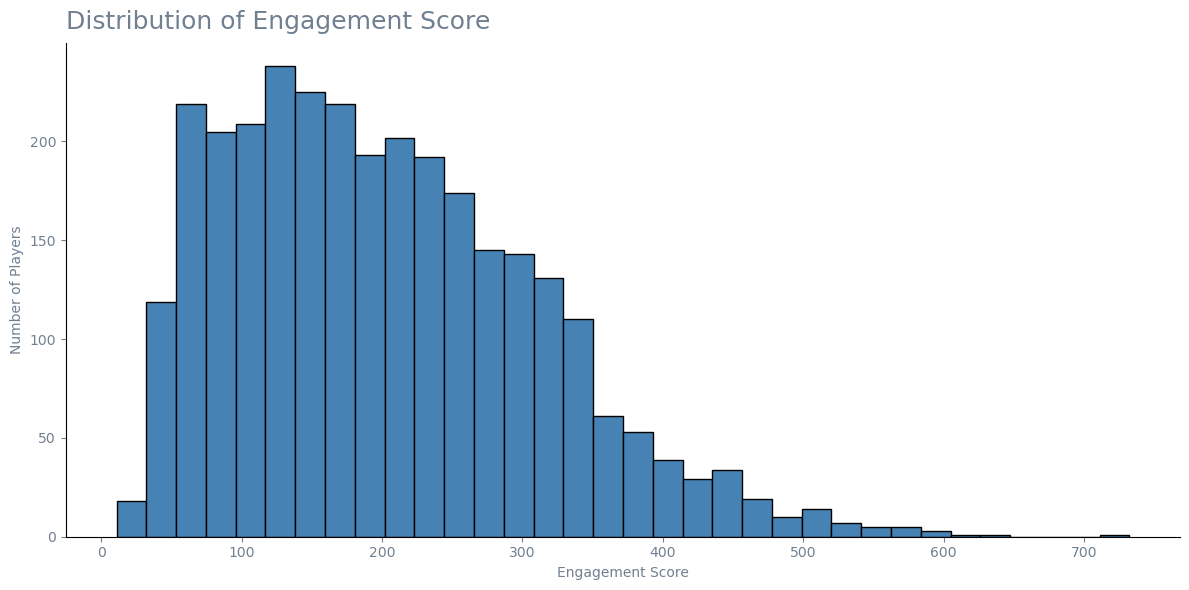

In [242]:
fig, ax = plt.subplots(figsize=(12,6))

ax.hist(
    df_games_final['EngagementScore'],
    bins='auto',
    color='steelblue',
    edgecolor='black',
    linewidth=1.0
)

ax.set_title(
    'Distribution of Engagement Score',
    fontsize=18,
    color='slategray',
    loc='left',
    pad=10
)

ax.set_xlabel('Engagement Score', color='slategray')
ax.set_ylabel('Number of Players', color='slategray')

ax.tick_params(colors='slategray')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [237]:
engagement_range

,EngagementSegment,min,max
0,Low,11.01,138.16
1,Medium,138.30,242.27
2,High,242.34,732.16


# The Engagement Score is distributed across a wide range of values, with most players concentrated in the lower and middle score ranges and progressively fewer players reaching very high engagement levels. Players were subsequently segmented into Low, Medium and High Engagement groups using quantile-based thresholds, providing a consistent framework for comparing player behaviour throughout the analysis.

# Number of Players by Game Genre

In [58]:
players_per_genre = (
    df_games_final
    .groupby("GameGenre", observed=False)["UserID"]
    .count()
    .reset_index(name="Players Count")
    .sort_values("Players Count", ascending=False)
)

players_per_genre

,GameGenre,Players Count
11,Sandbox,219
12,Simulation,219
13,Sports,217
4,Casual,209
8,Puzzle,206
3,Card,202
6,MMORPG,198
14,Strategy,198
10,Role Playing,193
0,Action RPG,191


# Correlation 

In [273]:
correlation_df = df_games_final[

['EngagementScore',
    'SessionCount',
    'AverageSessionLength',
    'FirstPurchaseDaysAfterInstall',
    'Age',
    'InAppPurchaseAmount']]

correlation_df.corr().round(2)

,EngagementScore,SessionCount,AverageSessionLength,FirstPurchaseDaysAfterInstall,Age,InAppPurchaseAmount
EngagementScore,1.00,0.56,0.78,0.02,0.01,0.00
SessionCount,0.56,1.00,-0.01,0.01,0.03,0.04
AverageSessionLength,0.78,-0.01,1.00,0.01,-0.01,-0.03
FirstPurchaseDaysAfterInstall,0.02,0.01,0.01,1.00,0.01,0.01
Age,0.01,0.03,-0.01,0.01,1.00,0.02
InAppPurchaseAmount,0.00,0.04,-0.03,0.01,0.02,1.00


# Scatterplot

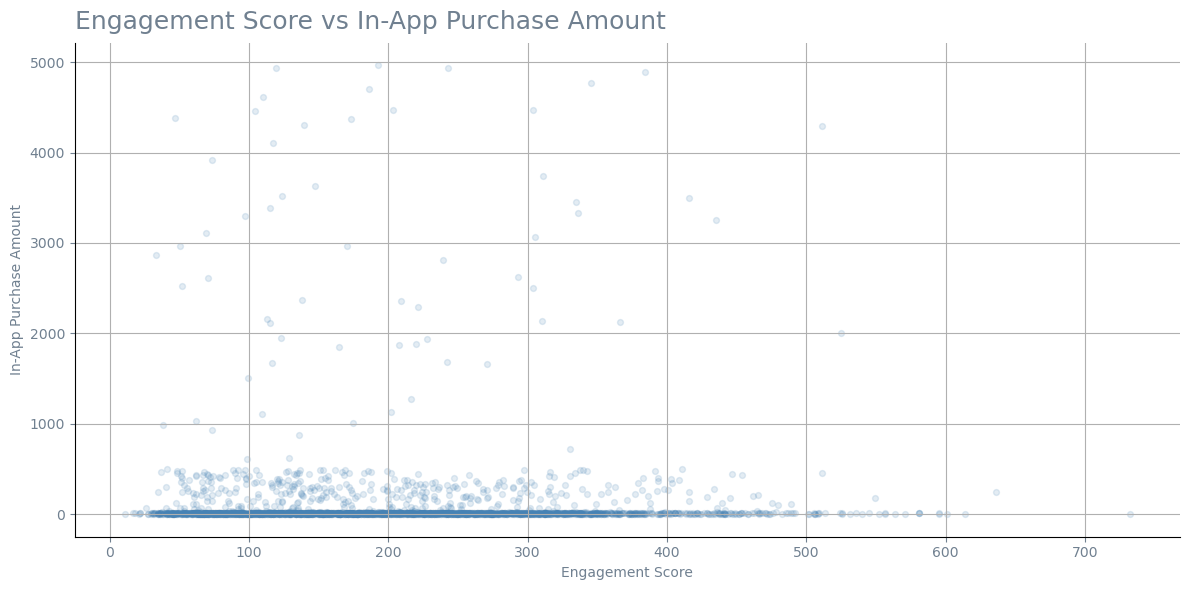

In [286]:
fig, ax = plt.subplots(figsize=(12,6))

ax.scatter(
    df_games_final['EngagementScore'],
    df_games_final['InAppPurchaseAmount'],
    color='steelblue',
    s=18,
    alpha=0.15
)

ax.set_title(
    'Engagement Score vs In-App Purchase Amount',
    fontsize=18,
    color='slategray',
    loc='left',
    pad=10
)

ax.set_xlabel('Engagement Score', color='slategray')
ax.set_ylabel('In-App Purchase Amount', color='slategray')

ax.tick_params(colors='slategray')

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

plt.grid(True)

plt.tight_layout()

plt.show()

# No meaningful linear relationship was found between player behaviour metrics and in-app purchase amount. Engagement Score, Session Count, Average Session Length and Age all exhibit correlation coefficients close to zero, suggesting that these variables alone do not explain monetization within this dataset.